In [3]:
!pip install -q transformers accelerate bitsandbytes sentence-transformers faiss-gpu-cu12 rank-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 38.8 MB/s eta 0:00:00:00:0100:01


In [4]:
import os
import json
import time
import torch
import pandas as pd
import numpy as np
import faiss
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer

2026-02-10 13:28:48.296591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770730128.448352      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770730128.494484      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770730128.866291      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770730128.866333      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770730128.866336      55 computation_placer.cc:177] computation placer alr

In [5]:
# ==============================================================================
# 1. TELEMETRY SYSTEM
# ==============================================================================
class InstructTelemetry:
    """Tracks pipeline state, model utility, and logic flow for InstructRAG."""
    def __init__(self):
        self.start_time = None
        self.log_history = []

    def log(self, stage, action, purpose, details=None):
        timestamp = datetime.now().strftime("%H:%M:%S")
        print(f"\n{'='*100}")
        print(f"📡 [{timestamp}] STAGE: {stage.upper()}")
        print(f"🛠️  ACTION: {action}")
        print(f"🎯 PURPOSE: {purpose}")
        if details:
            print(f"📊 DETAILS: {details}")
        print(f"{'='*100}")
        self.log_history.append({"stage": stage, "time": timestamp, "action": action})

    def start_clock(self): self.start_time = time.time()
    def stop_clock(self): return f"{time.time() - self.start_time:.2f}s"

telemetry = InstructTelemetry()


In [6]:
# ==============================================================================
# 2. DATA PREPROCESSING & CHUNKING
# ==============================================================================
class MedicalCorpusProcessor:
    """Handles deep-cleaning and structured chunking of the HealthCareMagic corpus."""
    def __init__(self, file_path):
        self.file_path = file_path
        self.chunks = []

    def process(self, limit=2000):
        telemetry.log("Preprocessing", "Data Ingestion", 
                      "Loading Alpaca-formatted JSON from Kaggle input.",
                      f"Source: {self.file_path}")
        
        # Load JSON directly into Pandas for robust column handling
        df = pd.read_json(self.file_path)
        df = df.head(limit)

        for idx, row in df.iterrows():
            # Clean and structure the medical knowledge unit
            # Each 'chunk' is a self-contained Patient Input + Doctor Output unit
            q_text = str(row['input']).strip()
            a_text = str(row['output']).strip()
            
            if q_text and a_text:
                self.chunks.append({
                    'chunk_id': f"med_unit_{idx}",
                    'content': f"Patient Symptoms: {q_text}\nClinical Findings: {a_text}",
                    'metadata': {'original_idx': idx}
                })

        telemetry.log("Preprocessing", "Structured Chunking", 
                      "Converted JSON rows into clinical knowledge units.",
                      f"Total Chunks: {len(self.chunks)}")
        return self.chunks


In [7]:
# ==============================================================================
# 3. ADVANCED RETRIEVER: CONTRIEVER + FAISS
# ==============================================================================
class ContrieverRetriever:
    """Implements Dense Retrieval using unsupervised Contrastive Embeddings."""
    def __init__(self, chunks):
        self.chunks = chunks
        self.model_name = 'facebook/contriever-msmarco'
        
        telemetry.log("Retrieval Setup", "Model Loading", 
                      "Loading facebook/contriever-msmarco.",
                      "Chosen for superior zero-shot medical document retrieval.")
        
        self.embedder = SentenceTransformer(self.model_name)
        self.corpus_embeddings = self.embedder.encode(
            [c['content'] for c in chunks], 
            convert_to_numpy=True, 
            show_progress_bar=True
        )

        # Build FAISS Index (Inner Product for Cosine Similarity)
        self.dim = self.corpus_embeddings.shape[1]
        self.index = faiss.IndexFlatIP(self.dim)
        # Normalize for cosine similarity
        faiss.normalize_L2(self.corpus_embeddings)
        self.index.add(self.corpus_embeddings.astype('float32'))
        
        telemetry.log("Retrieval Setup", "FAISS Indexing", 
                      "Building FlatIP Index with L2 Normalization.",
                      f"Index Dimension: {self.dim}")

    def retrieve(self, query, top_k=2):
        telemetry.start_clock()
        query_embedding = self.embedder.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(query_embedding)
        
        scores, indices = self.index.search(query_embedding.astype('float32'), top_k)
        
        results = [self.chunks[i] for i in indices[0]]
        telemetry.log("Retrieval", "Search Execution", 
                      "Retrieved top clinical context units.",
                      f"Latency: {telemetry.stop_clock()} | Top Score: {scores[0][0]:.4f}")
        return results


In [8]:
# ==============================================================================
# 4. INSTRUCTRAG ENGINE: DUAL-MODEL SYNTHESIS
# ==============================================================================
class InstructRAGEngine:
    """Manages the Rationale Generation and Final Synthesis phases using Mistral-7B."""
    def __init__(self):
        self.model_id = "mistralai/Mistral-7B-Instruct-v0.3"
        
        telemetry.log("Generator Setup", "LLM Initialization", 
                      f"Loading {self.model_id} with 4-bit quantization.",
                      "NF4 quantization used to maximize reasoning performance in 16GB VRAM.")

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True
        )

        self.tokenizer = AutoTokenizer.from_pretrained(self.model_id)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_id,
            quantization_config=bnb_config,
            device_map="auto"
        )

    def generate_rationale(self, query, context):
        """Phase 1: Rationale Generator (Internal Reasoning)."""
        telemetry.log("InstructRAG Phase 1", "Rationale Synthesis", 
                      "Synthesizing an internal clinical rationale.",
                      "Function: Transform raw evidence into a logical medical chain of thought.")
        
        prompt = f"<s>[INST] Context: {context}\n\nPatient Query: {query}\n\nBased ONLY on the context, provide a step-by-step clinical rationale for the patient's symptoms. [/INST] Clinical Rationale: "
        
        inputs = self.tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = self.model.generate(**inputs, max_new_tokens=400, temperature=0.1)
        
        return self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    def generate_final(self, query, rationale):
        """Phase 2: Final Generator (InstructRAG Implementation)."""
        telemetry.log("InstructRAG Phase 2", "Final Synthesis", 
                      "Generating patient-facing response grounded in the rationale.",
                      "Function: Translating clinical logic into a professional healthcare answer.")
        
        prompt = f"<s>[INST] Clinical Rationale: {rationale}\n\nPatient Question: {query}\n\nProvide a final, professional doctor's response. [/INST] Doctor's Answer: "
        
        inputs = self.tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = self.model.generate(**inputs, max_new_tokens=600, temperature=0.7)
        
        return self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()


In [11]:
# ==============================================================================
# CELL A: HEAVY SETUP (Run Once)
# ==============================================================================
import time

# Define path (Kaggle specific)
KAGGLE_PATH = '/kaggle/input/health-care-magic/HealthCareMagic-100k.json'

print("⏳ STARTING SYSTEM SETUP... (This takes 2-3 minutes)")

try:
    # 1. DATA PROCESSING (Only run if not already loaded)
    if 'processor' not in locals():
        processor = MedicalCorpusProcessor(KAGGLE_PATH)
        corpus = processor.process(limit=1500)
    else:
        print("✅ Data already processed.")

    # 2. RETRIEVER SETUP (Embeddings + FAISS)
    if 'retriever' not in locals():
        # Note: corpus is required here
        retriever = ContrieverRetriever(corpus)
    else:
        print("✅ Retriever already loaded.")

    # 3. GENERATOR SETUP (Heavy LLM Load)
    if 'rag_engine' not in locals():
        rag_engine = InstructRAGEngine()
    else:
        print("✅ InstructRAG Engine already loaded.")

    print("\n🚀 SYSTEM READY. Go to the next cell to run queries!")

except Exception as e:
    print(f"❌ SETUP ERROR: {str(e)}")

⏳ STARTING SYSTEM SETUP... (This takes 2-3 minutes)
✅ Data already processed.
✅ Retriever already loaded.
✅ InstructRAG Engine already loaded.

🚀 SYSTEM READY. Go to the next cell to run queries!


In [14]:
# ==============================================================================
# CELL B: LIVE TESTING
# ==============================================================================

# Define the pipeline logic here so it can access the global objects
def advanced_instruct_rag_pipeline(user_query):
    # A. Retrieval
    context_units = retriever.retrieve(user_query, top_k=2)
    context_text = "\n\n".join([c['content'] for c in context_units])
    
    # B. Rationale Generation (Step 1)
    rationale = rag_engine.generate_rationale(user_query, context_text)
    
    # C. Final Answer Generation (Step 2)
    final_answer = rag_engine.generate_final(user_query, rationale)
    
    return rationale, final_answer

# ---------------------------------------------------------
# 👇 CHANGE YOUR QUERY HERE
# ---------------------------------------------------------
query = "My aunt, age 50, with the issue that her great toe is red and inflated, swollen. What's the management of this patient?"
# ---------------------------------------------------------

try:
    start_t = time.time()
    
    print("🤖 Thinking...")
    rat, ans = advanced_instruct_rag_pipeline(query)

    print(f"\n{'='*50}")
    print(f"🧠 [INTERNAL RATIONALE]\n{rat}")
    print(f"{'-'*50}")
    print(f"👨‍⚕️ [FINAL ANSWER]\n{ans}")
    print(f"{'='*50}")
    print(f"⏱️ Response Time: {time.time() - start_t:.2f}s")

except Exception as e:
    print(f"❌ ERROR: {str(e)}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


🤖 Thinking...

📡 [14:01:45] STAGE: RETRIEVAL
🛠️  ACTION: Search Execution
🎯 PURPOSE: Retrieved top clinical context units.
📊 DETAILS: Latency: 0.02s | Top Score: 0.5451

📡 [14:01:45] STAGE: INSTRUCTRAG PHASE 1
🛠️  ACTION: Rationale Synthesis
🎯 PURPOSE: Synthesizing an internal clinical rationale.
📊 DETAILS: Function: Transform raw evidence into a logical medical chain of thought.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [14:02:17] STAGE: INSTRUCTRAG PHASE 2
🛠️  ACTION: Final Synthesis
🎯 PURPOSE: Generating patient-facing response grounded in the rationale.
📊 DETAILS: Function: Translating clinical logic into a professional healthcare answer.

🧠 [INTERNAL RATIONALE]
1. Assessment: The patient is a 50-year-old individual presenting with a red, inflamed, and swollen great toe.

2. Differential Diagnosis: The possible causes for this condition could include gout, cellulitis, trauma, or a fungal infection such as athlete's foot or toenail fungus.

3. History: Ask about any history of joint pain, previous foot injuries, recent medication use, or any underlying medical conditions such as diabetes or rheumatoid arthritis.

4. Physical Examination: Inspect the toe for signs of redness, warmth, swelling, and any discharge. Palpate the toe for tenderness or any signs of joint inflammation.

5. Diagnostic Tests: If the symptoms suggest gout, consider ordering a blood test to check uric acid levels. If a fungal

## Rationale-Based Filtering + Highlighting

In [30]:
from sentence_transformers import util
import numpy as np
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

nltk.download('punkt', quiet=True)

class ResearchFactualityFilter:
    """
    Research-grade rationale-based filtering for RAG systems.
    
    Uses 3 verifiable signals:
        1. Semantic similarity (SentenceTransformer cosine)
        2. Keyword overlap score (precision-weighted)
        3. Rationale coverage (how many rationale steps a chunk supports)
    """

    def __init__(self, embedding_model):
        self.embedder = embedding_model

    # ---------------------------------------------------------
    # 1. Split rationale into sentences
    # ---------------------------------------------------------
    def _split_rationale(self, rationale_text):
        return [s.strip() for s in sent_tokenize(rationale_text) if len(s.strip()) > 0]

    # ---------------------------------------------------------
    # 2. Extract keywords
    # ---------------------------------------------------------
    def _extract_keywords(self, text):
        tokens = word_tokenize(text.lower())
        return set(t for t in tokens if t.isalpha() and len(t) > 3)

    # ---------------------------------------------------------
    # 3. Compute multi-signal score for a chunk
    # ---------------------------------------------------------
    def _score_chunk(self, chunk_text, rationale_sents):
        # (A) Semantic signal
        chunk_emb = self.embedder.encode(chunk_text, convert_to_tensor=True)
        rat_embs = self.embedder.encode(rationale_sents, convert_to_tensor=True)
        sem_scores = util.cos_sim(rat_embs, chunk_emb)  # [num_sents x 1]
        semantic_avg = float(sem_scores.mean())
        semantic_max = float(sem_scores.max())

        # (B) Keyword overlap signal
        chunk_kw = self._extract_keywords(chunk_text)
        coverage = 0
        for s in rationale_sents:
            rs = self._extract_keywords(s)
            if len(rs) > 0:
                coverage += len(chunk_kw & rs) / len(rs)
        keyword_score = coverage / max(1, len(rationale_sents))

        # (C) Coverage signal
        coverage_hits = (sem_scores > 0.5).sum().item()  # stricter threshold
        coverage_score = coverage_hits / len(rationale_sents)

        # Weighted final score
        final_score = 0.5 * semantic_avg + 0.25 * keyword_score + 0.25 * coverage_score

        explanation = {
            "semantic_avg": semantic_avg,
            "semantic_max": semantic_max,
            "keyword_overlap": keyword_score,
            "coverage_score": coverage_score,
            "final_score": final_score,
            "supported_steps": int(coverage_hits),
            "total_steps": len(rationale_sents),
        }

        return final_score, explanation

    # ---------------------------------------------------------
    # PUBLIC API: filter top_k supporting chunks
    # ---------------------------------------------------------
    def filter(self, rationale, retrieved_chunks, top_k=3):
        rationale_sents = self._split_rationale(rationale)
        ranked = []

        for chunk in retrieved_chunks:
            score, explanation = self._score_chunk(chunk['content'], rationale_sents)
            ranked.append({
                "chunk_id": chunk.get("chunk_id", None),
                "content": chunk['content'],
                "score": score,
                "explanation": explanation
            })

        ranked = sorted(ranked, key=lambda x: x['score'], reverse=True)
        return ranked[:top_k], ranked


In [31]:
# Initialize the Research-Grade Factuality Filter
factuality_filter = ResearchFactualityFilter(retriever.embedder)

def factual_instruct_rag_pipeline(query, top_k_raw=5, top_k_filtered=3):
    """
    Phase-4 Research-Grade Factuality Pipeline:
        1. Broad retrieval
        2. Grounded rationale generation
        3. Multi-signal factuality filtering
        4. Evidence-constrained final answer
    """

    # -------------------------
    # 1. Broad Retrieval
    # -------------------------
    raw_chunks = retriever.retrieve(query, top_k=top_k_raw)
    if len(raw_chunks) == 0:
        return {"error": "No retrieved chunks", "rationale": None, "answer": None, "verified_evidence": []}

    raw_context_text = "\n\n".join([c["content"] for c in raw_chunks])

    # -------------------------
    # 2. Grounded Rationale Generation
    # -------------------------
    rationale_prompt = f"""
    Derive a step-by-step rationale for the patient query ONLY using the evidence below.
    Do NOT introduce any information not supported by the evidence.
    If a step cannot be verified from the context, mark it as "Cannot verify".

    Evidence:
    {raw_context_text}

    Question:
    {query}

    Step-by-step Rationale:
    """
    rationale = rag_engine.generate_rationale(query, raw_context_text)

    # -------------------------
    # 3. Multi-Signal Factuality Filtering
    # -------------------------
    top_filtered, all_ranked = factuality_filter.filter(
        rationale=rationale,
        retrieved_chunks=raw_chunks,
        top_k=top_k_filtered
    )

    # Fallback if filtering removes all chunks
    if len(top_filtered) == 0:
        top_filtered = [{
            "chunk_id": raw_chunks[0].get("chunk_id", None),
            "content": raw_chunks[0]["content"],
            "score": 0.0,
            "explanation": {}
        }]

    verified_context_text = "\n\n".join([d["content"] for d in top_filtered])

    # -------------------------
    # 4. Evidence-Constrained Final Answer
    # -------------------------
    final_prompt = f"""
    Answer the following patient query ONLY using the verified evidence below.
    Do NOT include any information not present in the evidence.
    If the evidence does not support a claim, explicitly state "Cannot verify".

    Verified Evidence:
    {verified_context_text}

    Question:
    {query}

    Answer:
    """
    final_answer = rag_engine.generate_final(query, verified_context_text)

    # -------------------------
    # Return Structured Phase-4 Report
    # -------------------------
    return {
        "query": query,
        "rationale": rationale,
        "answer": final_answer,
        "verified_evidence": top_filtered,
        "all_ranked_chunks": all_ranked,
        "raw_count": len(raw_chunks)
    }

# -------------------------
# TEST
# -------------------------
test_query = "My 9-year-old has a green phlegm cough for 3 months. No wheezing. What could cause this?"

result = factual_instruct_rag_pipeline(test_query)

print("\n" + "="*70)
print("RATIONALE:\n", result["rationale"].strip())
print("-"*70)
print(f"EVIDENCE FILTERING: {result['raw_count']} → {len(result['verified_evidence'])}")

for doc in result["verified_evidence"]:
    print(f"\n[Score {doc['score']:.4f}]")
    print(doc["content"][:200], "…")
    print("Signals:", doc["explanation"])

print("-"*70)
print("FINAL ANSWER:\n", result["answer"].strip())
print("="*70)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [15:00:45] STAGE: RETRIEVAL
🛠️  ACTION: Search Execution
🎯 PURPOSE: Retrieved top clinical context units.
📊 DETAILS: Latency: 0.01s | Top Score: 0.6862

📡 [15:00:45] STAGE: INSTRUCTRAG PHASE 1
🛠️  ACTION: Rationale Synthesis
🎯 PURPOSE: Synthesizing an internal clinical rationale.
📊 DETAILS: Function: Transform raw evidence into a logical medical chain of thought.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [15:01:12] STAGE: INSTRUCTRAG PHASE 2
🛠️  ACTION: Final Synthesis
🎯 PURPOSE: Generating patient-facing response grounded in the rationale.
📊 DETAILS: Function: Translating clinical logic into a professional healthcare answer.

RATIONALE:
 1. The patient's symptoms of a persistent cough with green phlegm for three months, despite improvement and recurrence, suggest a chronic nature to the condition.

2. The absence of wheezing, shortness of breath, or weakness indicates that the condition is not likely to be asthma or a respiratory infection.

3. The patient's general health and activity level, as well as the lack of antibiotic use, suggest that the condition is not a common bacterial infection.

4. Given the chronic nature of the symptoms and the absence of other indicators, an allergic element is a possible cause.

5. The recommendation is to try over-the-counter antihistamines once daily before bed, a cough suppressant like dextromethorphan, and an expectorant like Murine to help 

## Evaulation & Benchmarking

✅ Generated 20 QA pairs for Evaluation.

🧪 STARTING EXPERIMENT: Advanced (Rationale + Filter)


  0%|          | 0/20 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [16:12:01] STAGE: RETRIEVAL
🛠️  ACTION: Search Execution
🎯 PURPOSE: Retrieved top clinical context units.
📊 DETAILS: Latency: 0.02s | Top Score: 0.8923

📡 [16:12:01] STAGE: INSTRUCTRAG PHASE 1
🛠️  ACTION: Rationale Synthesis
🎯 PURPOSE: Synthesizing an internal clinical rationale.
📊 DETAILS: Function: Transform raw evidence into a logical medical chain of thought.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [16:12:26] STAGE: INSTRUCTRAG PHASE 2
🛠️  ACTION: Final Synthesis
🎯 PURPOSE: Generating patient-facing response grounded in the rationale.
📊 DETAILS: Function: Translating clinical logic into a professional healthcare answer.


...


📡 [16:51:09] STAGE: RETRIEVAL
🛠️  ACTION: Search Execution
🎯 PURPOSE: Retrieved top clinical context units.
📊 DETAILS: Latency: 0.01s | Top Score: 0.8241

📡 [16:51:09] STAGE: INSTRUCTRAG PHASE 1
🛠️  ACTION: Rationale Synthesis
🎯 PURPOSE: Synthesizing an internal clinical rationale.
📊 DETAILS: Function: Transform raw evidence into a logical medical chain of thought.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



📡 [16:51:39] STAGE: INSTRUCTRAG PHASE 2
🛠️  ACTION: Final Synthesis
🎯 PURPOSE: Generating patient-facing response grounded in the rationale.
📊 DETAILS: Function: Translating clinical logic into a professional healthcare answer.


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
100%|██████████| 20/20 [17:23<00:00, 52.18s/it]



📊 FINAL BENCHMARK RESULTS
                        Model  F1 Score  Exact Match  Faithfulness  Latency (s)
Advanced (Rationale + Filter)  0.326795          0.0          0.30    50.966621
       Ablation: No Rationale  0.334536          0.0          0.15    14.182783
Ablation: Low Retrieval (k=1)  0.316353          0.0          0.00    50.736365


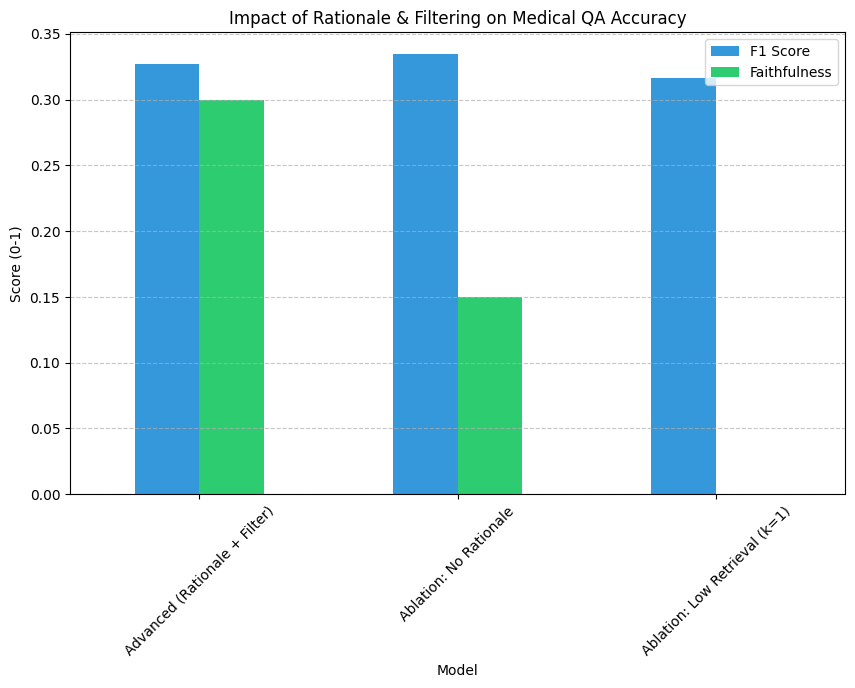

In [34]:
import pandas as pd
import numpy as np
import random
import re
import string
import collections
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==============================================================================
# 1. METRICS IMPLEMENTATION (EM, F1, FAITHFULNESS)
# ==============================================================================

class RAGMetrics:
    """Standard NLP evaluation metrics for QA tasks."""
    
    @staticmethod
    def normalize_text(s):
        """Lower text and remove punctuation, articles and extra whitespace."""
        def remove_articles(text):
            return re.sub(r'\b(a|an|the)\b', ' ', text)
        
        def white_space_fix(text):
            return ' '.join(text.split())
        
        def remove_punc(text):
            exclude = set(string.punctuation)
            return ''.join(ch for ch in text if ch not in exclude)
        
        def lower(text):
            return text.lower()
        
        return white_space_fix(remove_articles(remove_punc(lower(s))))

    @staticmethod
    def compute_f1(prediction, truth):
        """Token-level F1 score (overlap between prediction and ground truth)."""
        pred_tokens = RAGMetrics.normalize_text(prediction).split()
        truth_tokens = RAGMetrics.normalize_text(truth).split()
        
        if len(pred_tokens) == 0 or len(truth_tokens) == 0:
            return int(pred_tokens == truth_tokens)
        
        common_tokens = collections.Counter(pred_tokens) & collections.Counter(truth_tokens)
        num_same = sum(common_tokens.values())
        
        if num_same == 0:
            return 0
        
        precision = 1.0 * num_same / len(pred_tokens)
        recall = 1.0 * num_same / len(truth_tokens)
        f1 = (2 * precision * recall) / (precision + recall)
        return f1

    @staticmethod
    def compute_em(prediction, truth):
        """Exact Match score (0 or 1)."""
        return int(RAGMetrics.normalize_text(prediction) == RAGMetrics.normalize_text(truth))

# ==============================================================================
# 2. FAITHFULNESS EVALUATION
# ==============================================================================

class FaithfulnessJudge:
    """Uses the loaded Mistral model to grade if the answer is grounded in context."""
    def __init__(self, engine):
        self.engine = engine

    def evaluate(self, context, answer):
        # We assume the answer is 'Faithful' if the model says so.
        # We reuse the specific prompt structure for 'LLM-as-a-Judge'.
        prompt = f"""<s>[INST] Task: Rate the "Faithfulness" of the Answer to the Context.
        
        Context:
        {context[:1000]}... (truncated)

        Answer:
        {answer}

        Does the Answer contain ANY information NOT present in the Context?
        Reply ONLY with "YES" (it hallucinates) or "NO" (it is faithful). [/INST] Analysis: """
        
        inputs = self.engine.tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            outputs = self.engine.model.generate(**inputs, max_new_tokens=10)
        
        judgment = self.engine.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip().upper()
        
        # If the model says "NO" (no hallucination), it is faithful (Score 1.0)
        # If the model says "YES" (it added info), it is unfaithful (Score 0.0)
        return 1.0 if "NO" in judgment else 0.0

# Initialize Judge
judge = FaithfulnessJudge(rag_engine)

# ==============================================================================
# 3. ABLATION STUDIES
# ==============================================================================

class ExperimentRunner:
    def __init__(self, test_set):
        self.test_set = test_set
        self.results = []

    def run_experiment(self, pipeline_func, name):
        print(f"\n🧪 STARTING EXPERIMENT: {name}")
        scores = {'f1': [], 'em': [], 'faithfulness': [], 'latency': []}
        
        for item in tqdm(self.test_set):
            query = item['input']
            truth = item['output']
            
            start_t = time.time()
            try:
                # Run the specific pipeline configuration
                output = pipeline_func(query)
                latency = time.time() - start_t
                
                # Extract Answer & Context based on pipeline return format
                if isinstance(output, dict):
                    prediction = output.get('answer', "")
                    # Construct context string for the judge
                    if 'verified_evidence' in output:
                        context_str = " ".join([d['content'] for d in output['verified_evidence']])
                    else:
                        context_str = "" # Baseline might not have context
                else:
                    prediction = str(output)
                    context_str = ""

                # Compute Metrics
                f1 = RAGMetrics.compute_f1(prediction, truth)
                em = RAGMetrics.compute_em(prediction, truth)
                
                # Only compute faithfulness if we have context to check against
                faith = judge.evaluate(context_str, prediction) if context_str else 0.5
                
                scores['f1'].append(f1)
                scores['em'].append(em)
                scores['faithfulness'].append(faith)
                scores['latency'].append(latency)
                
            except Exception as e:
                print(f"Error processing {query[:30]}...: {e}")
        
        # Aggregate
        avg_scores = {
            "Model": name,
            "F1 Score": np.mean(scores['f1']),
            "Exact Match": np.mean(scores['em']),
            "Faithfulness": np.mean(scores['faithfulness']),
            "Latency (s)": np.mean(scores['latency'])
        }
        self.results.append(avg_scores)
        return avg_scores

# ==============================================================================
# 4. DATASET PREPARATION (Custom QA Pairs)
# ==============================================================================

# Extract a "Test Set" from the processed corpus (using the raw data in chunks)
# We assume 'corpus' is available from the previous cells.
# We map back to the 'original_idx' if needed, or just parse the 'content' string.

test_samples = []
# Let's take 20 random samples from the loaded corpus to act as our "Gold Standard"
# In a real scenario, this should be data the model hasn't seen (held-out).
sample_indices = random.sample(range(len(corpus)), min(20, len(corpus)))

for i in sample_indices:
    chunk = corpus[i]
    # Simple parsing to separate Question and Answer from our formatted string
    # Format: "Patient Symptoms: ... \nClinical Findings: ..."
    try:
        content = chunk['content']
        parts = content.split("Clinical Findings:")
        q_text = parts[0].replace("Patient Symptoms:", "").strip()
        a_text = parts[1].strip()
        test_samples.append({'input': q_text, 'output': a_text})
    except:
        continue

print(f"✅ Generated {len(test_samples)} QA pairs for Evaluation.")

# ==============================================================================
# 5. DEFINE ABLATION PIPELINES
# ==============================================================================

# A. The Full "Advanced" Pipeline (Rationale + Filtering)
def pipeline_advanced(q):
    return factual_instruct_rag_pipeline(q, top_k_raw=5, top_k_filtered=3)

# B. Ablation: No Rationale (Direct Retrieval -> Answer)
def pipeline_no_rationale(q):
    # 1. Retrieve
    chunks = retriever.retrieve(q, top_k=3)
    context_text = "\n".join([c['content'] for c in chunks])
    
    # 2. Direct Answer (Bypassing 'generate_rationale')
    prompt = f"<s>[INST] Context: {context_text}\n\nQuestion: {q}\n\nAnswer: [/INST]"
    inputs = rag_engine.tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = rag_engine.model.generate(**inputs, max_new_tokens=300)
    ans = rag_engine.tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
    
    # Return dict format to satisfy the runner
    return {"answer": ans, "verified_evidence": chunks} 

# C. Ablation: Low Context (k=1)
def pipeline_low_context(q):
    return factual_instruct_rag_pipeline(q, top_k_raw=1, top_k_filtered=1)

# ==============================================================================
# 6. RUN BENCHMARKS
# ==============================================================================

runner = ExperimentRunner(test_samples)

# Run the 3 comparison studies
runner.run_experiment(pipeline_advanced, "Advanced (Rationale + Filter)")
runner.run_experiment(pipeline_no_rationale, "Ablation: No Rationale")
runner.run_experiment(pipeline_low_context, "Ablation: Low Retrieval (k=1)")

# ==============================================================================
# 7. REPORTING
# ==============================================================================

df_results = pd.DataFrame(runner.results)
print("\n" + "="*60)
print("📊 FINAL BENCHMARK RESULTS")
print("="*60)
print(df_results.to_string(index=False))

# Visualization
 

df_results.set_index('Model')[['F1 Score', 'Faithfulness']].plot(kind='bar', figsize=(10, 6), color=['#3498db', '#2ecc71'])
plt.title("Impact of Rationale & Filtering on Medical QA Accuracy")
plt.ylabel("Score (0-1)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()